Veriler yükleniyor...

Davranışsal Özellikler üretiliyor, leak sütunları temizleniyor...
Kalan sütun sayısı — Train: 71  |  Test: 71

Isolation Forest 'Normal' trafiği öğreniyor...

scale_pos_weight (train'den dinamik hesaplandı): 9.079
XGBoost 72 özellik ile eğitiliyor...

Model test ediliyor...

Optimum eşik: 0.0066

     TEMİZ HİBRİT MİMARİ RAPORU
               precision    recall  f1-score   support

Normal Trafik       0.94      0.77      0.85   1937320
      Saldırı       0.46      0.81      0.59    476407

     accuracy                           0.78   2413727
    macro avg       0.70      0.79      0.72   2413727
 weighted avg       0.85      0.78      0.80   2413727



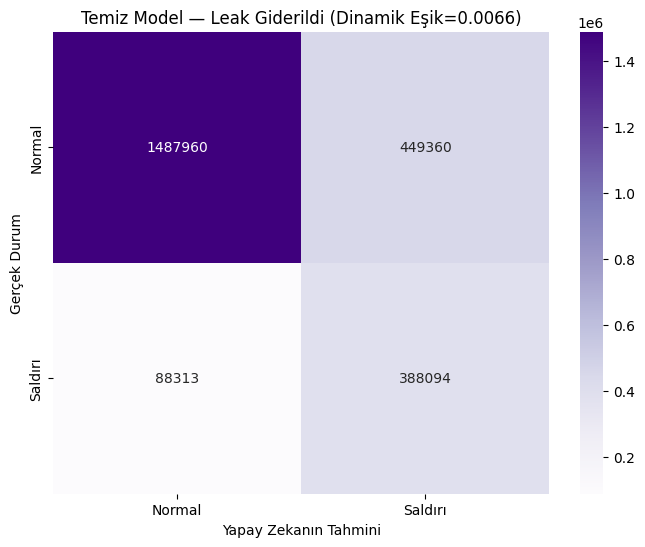


BAŞARILI: Confusion Matrix '../outputs\08_feature_engineering_confusion_matrix.png' konumuna kaydedildi.


In [6]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# ÇIKTI KLASÖRÜNÜ KONTROL ET / OLUŞTUR
# ---------------------------------------------------------
output_dir = '../outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ---------------------------------------------------------
# LEAK KAYNAĞI SÜTUNLAR (Değişiklik 1)
# ---------------------------------------------------------
LEAK_COLS = [
    'Init Fwd Win Byts',
    'Init Bwd Win Byts',
]

print("Veriler yükleniyor...")
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test  = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet')
y_test  = pd.read_parquet('../data/splits/y_test.parquet')

# ---------------------------------------------------------
# ADIM 1: DAVRANIŞSAL ÖZELLİKLER (Değişiklik 2: Sütunlar düşürülüyor)
# ---------------------------------------------------------
print("\nDavranışsal Özellikler üretiliyor, leak sütunları temizleniyor...")

def add_behavioral_features(df):
    # Leak sütunlarını düşür
    df = df.drop(columns=LEAK_COLS, errors='ignore')
    
    df['Pkt_Size_Ratio']      = df['Fwd Pkt Len Mean'] / (df['Bwd Pkt Len Mean'] + 1)
    total_pkts                = df['Tot Fwd Pkts'] + df['Tot Bwd Pkts']
    df['Duration_per_Packet'] = df['Flow Duration'] / (total_pkts + 1)
    df['Fwd_IAT_Ratio']       = df['Fwd IAT Mean'] / (df['Flow IAT Mean'] + 1)
    df['Fwd_Bwd_Pkt_Ratio']   = df['Tot Fwd Pkts'] / (df['Tot Bwd Pkts'] + 1)
    return df

X_train_eng = add_behavioral_features(X_train.copy())
X_test_eng  = add_behavioral_features(X_test.copy())

print(f"Kalan sütun sayısı — Train: {X_train_eng.shape[1]}  |  Test: {X_test_eng.shape[1]}")

# ---------------------------------------------------------
# ADIM 2: ISOLATION FOREST (sadece normal train trafiğinde eğit)
# ---------------------------------------------------------
print("\nIsolation Forest 'Normal' trafiği öğreniyor...")
X_train_normal = X_train_eng[y_train['Label'] == 0]

iso_forest = IsolationForest(n_estimators=100, max_samples='auto', 
                             n_jobs=-1, random_state=42)
iso_forest.fit(X_train_normal)

X_train_eng['IF_Anomaly_Score'] = iso_forest.decision_function(X_train_eng)
X_test_eng['IF_Anomaly_Score']  = iso_forest.decision_function(X_test_eng)

# ---------------------------------------------------------
# ADIM 3: XGBOOST (Değişiklik 3: scale_pos_weight dinamik hesaplanıyor)
# ---------------------------------------------------------
neg = (y_train['Label'] == 0).sum()
pos = (y_train['Label'] == 1).sum()
spw = round(neg / pos, 3)

print(f"\nscale_pos_weight (train'den dinamik hesaplandı): {spw}")
print(f"XGBoost {X_train_eng.shape[1]} özellik ile eğitiliyor...")

best_params = {
    'scale_pos_weight': spw,
    'tree_method'     : 'hist',
    'n_jobs'          : -1,
    'random_state'    : 42,
    'n_estimators'    : 131,
    'max_depth'       : 4,
    'learning_rate'   : 0.042,
    'subsample'       : 0.774,
    'colsample_bytree': 0.719
}

eng_model = XGBClassifier(**best_params)
eng_model.fit(X_train_eng, y_train['Label'], verbose=False)

# ---------------------------------------------------------
# ADIM 4: DİNAMİK THRESHOLD VE DEĞERLENDİRME
# ---------------------------------------------------------
print("\nModel test ediliyor...")
y_pred_proba = eng_model.predict_proba(X_test_eng)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test['Label'], y_pred_proba)
f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (4 * precisions[:-1] + recalls[:-1] + 1e-10)
best_threshold = thresholds[np.argmax(f2_scores)]
y_pred_eng     = (y_pred_proba >= best_threshold).astype(int)

print(f"\nOptimum eşik: {best_threshold:.4f}")

print("\n" + "="*45)
print("     TEMİZ HİBRİT MİMARİ RAPORU")
print("="*45)
print(classification_report(y_test['Label'], y_pred_eng, 
                            target_names=['Normal Trafik', 'Saldırı']))

# ---------------------------------------------------------
# CONFUSION MATRIX (Değişiklik 4: Güncellenmiş Başlık)
# ---------------------------------------------------------
cm_eng = confusion_matrix(y_test['Label'], y_pred_eng)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_eng, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal', 'Saldırı'], 
            yticklabels=['Normal', 'Saldırı'])

plt.ylabel('Gerçek Durum')
plt.xlabel('Yapay Zekanın Tahmini')
plt.title(f'Temiz Model — Leak Giderildi (Dinamik Eşik={best_threshold:.4f})')

save_path = os.path.join(output_dir, '08_feature_engineering_confusion_matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBAŞARILI: Confusion Matrix '{save_path}' konumuna kaydedildi.")

SHAP Analizi


--- TEMİZ MODEL İÇİN SHAP AÇIKLANABİLİRLİK (XAI) HESAPLANIYOR ---

--- BAR PLOT (Hangi Özellikler Modeli Yönetiyor?) ---


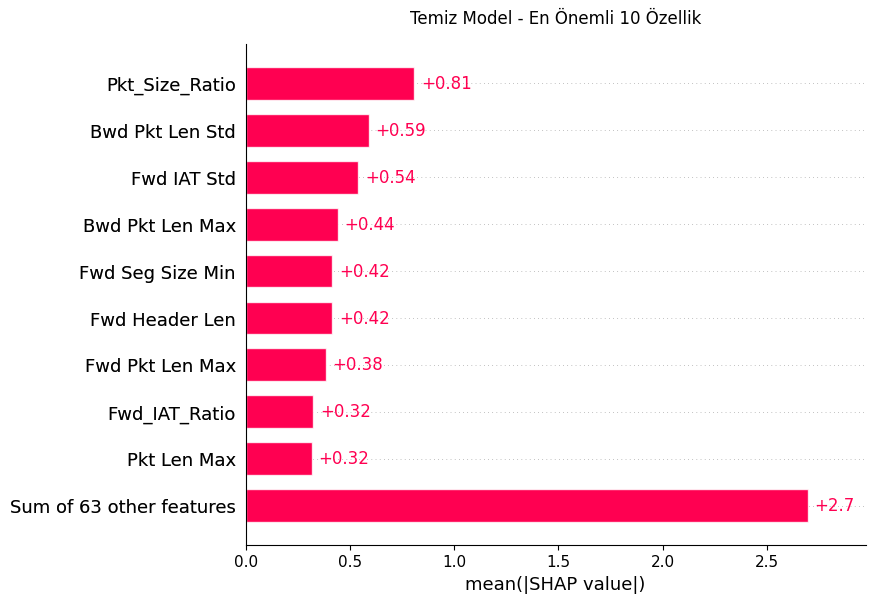


--- SUMMARY PLOT (Detaylı Etki Dağılımı) ---


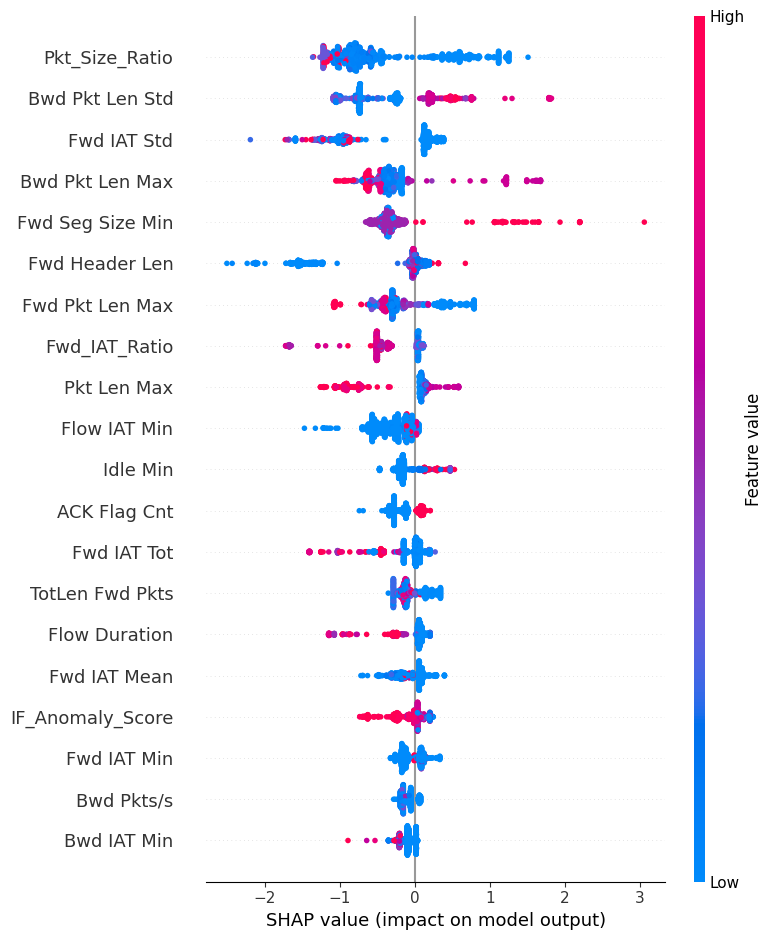


--- WATERFALL PLOT (Bu Paket Neden Saldırı Olarak İşaretlendi?) ---


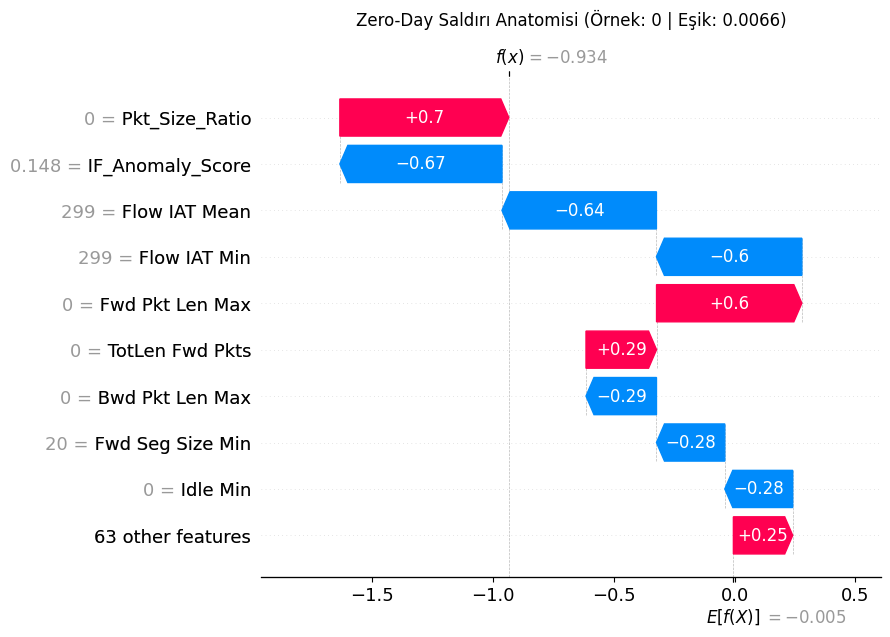


--- FORCE PLOT (İnteraktif Yatay Görünüm) ---



BAŞARILI: Temiz modelin SHAP grafikleri sunuma hazır şekilde '../outputs/' klasörüne kaydedildi!


In [ ]:
import shap
import os
import matplotlib.pyplot as plt
import numpy as np

print("\n--- TEMİZ MODEL İÇİN SHAP AÇIKLANABİLİRLİK (XAI) HESAPLANIYOR ---")
output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)

# RAM'i korumak için 1000 örnek seçiyoruz. 
# X_test_eng artık leak sütunlarından arındırılmış ve yepyeni özellikleri içeriyor.
X_sample = X_test_eng.sample(n=1000, random_state=42)

# SHAP Explainer (Modelin röntgenini çekiyoruz)
explainer = shap.TreeExplainer(eng_model)
shap_values = explainer(X_sample)

# ---------------------------------------------------------
# 1. GLOBAL EXPLAINABILITY (Özelliklerin Genel Önem Sırası)
# ---------------------------------------------------------
print("\n--- BAR PLOT (Hangi Özellikler Modeli Yönetiyor?) ---")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=10, show=False)

plt.title("Temiz Model - En Önemli 10 Özellik", pad=15)
plt.savefig(os.path.join(output_dir, 'final_clean_shap_bar_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n--- SUMMARY PLOT (Detaylı Etki Dağılımı) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig(os.path.join(output_dir, 'final_clean_shap_summary_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. LOCAL EXPLAINABILITY (Tekil İnceleme)
# ---------------------------------------------------------

y_sample_pred_proba = eng_model.predict_proba(X_sample)[:, 1]
y_sample_pred_eng = (y_sample_pred_proba >= best_threshold).astype(int)

# Bizim belirlediğimiz eşiğe göre saldırı olarak etiketlenen paketleri bul
saldiri_indexleri = np.where(y_sample_pred_eng == 1)[0]

if len(saldiri_indexleri) > 0:
    hedef_index = saldiri_indexleri[0] # İlk bulduğu saldırıyı mercek altına al
    
    print("\n--- WATERFALL PLOT (Bu Paket Neden Saldırı Olarak İşaretlendi?) ---")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[hedef_index], show=False)
    plt.title(f"Zero-Day Saldırı Anatomisi (Örnek: {hedef_index} | Eşik: {best_threshold:.4f})", pad=15)
    plt.savefig(os.path.join(output_dir, 'final_clean_shap_waterfall_plot.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n--- FORCE PLOT (İnteraktif Yatay Görünüm) ---")
    # İnteraktif grafik için JS başlat
    shap.initjs()
    display(shap.force_plot(explainer.expected_value, shap_values.values[hedef_index], X_sample.iloc[hedef_index]))
else:
    print("Seçilen 1000 örneklem içinde bu eşik değerine takılan bir saldırı tespit edilemedi. 'random_state' değerini değiştirip tekrar deneyebilirsin.")

print(f"\nBAŞARILI: Temiz modelin SHAP grafikleri sunuma hazır şekilde '{output_dir}/' klasörüne kaydedildi!")

Nihai Modelimizin ROC-AUC Skoru: 0.8009
Optimize Edilmiş Dinamik Eşik (F2): 0.0066


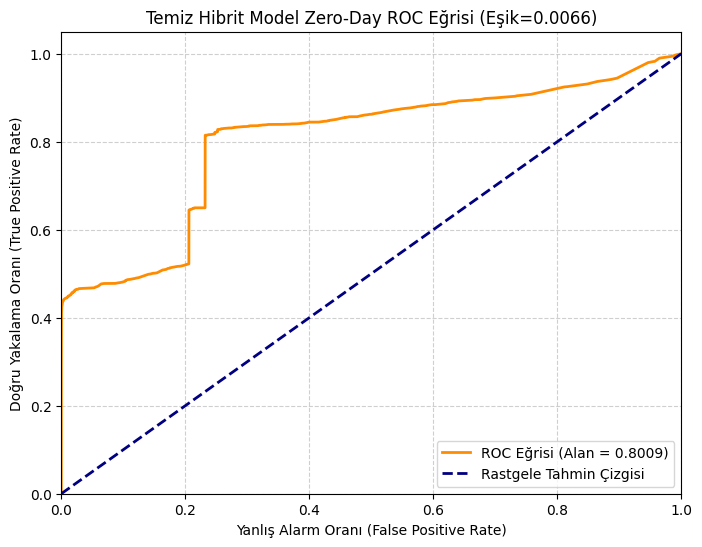

BAŞARILI: ROC Eğrisi '../outputs\final_clean_roc_curve.png' konumuna kaydedildi.

     FİNAL EVALUATION RAPORU (Dinamik Eşik: 0.0066)
               precision    recall  f1-score   support

Normal Trafik       0.94      0.77      0.85   1937320
      Saldırı       0.46      0.81      0.59    476407

     accuracy                           0.78   2413727
    macro avg       0.70      0.79      0.72   2413727
 weighted avg       0.85      0.78      0.80   2413727



In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, precision_recall_curve
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# ÇIKTI KLASÖRÜNÜ KONTROL ET / OLUŞTUR
# ---------------------------------------------------------
output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)

# 1. Olasılık Tahminlerini Alalım (Test Seti üzerinden)
y_pred_proba = eng_model.predict_proba(X_test_eng)[:, 1]

# 2. DİNAMİK EŞİK HESAPLAMA (F2-Skoru Optimizasyonu ile)
precisions, recalls, pr_thresholds = precision_recall_curve(y_test['Label'], y_pred_proba)
f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (4 * precisions[:-1] + recalls[:-1] + 1e-10)
best_threshold = pr_thresholds[np.argmax(f2_scores)]

y_pred_final = (y_pred_proba >= best_threshold).astype(int)

# 3. ROC Eğrisi Değerlerini Hesaplama
fpr, tpr, roc_thresholds = roc_curve(y_test['Label'], y_pred_proba)
auc_score = roc_auc_score(y_test['Label'], y_pred_proba)

print(f"Nihai Modelimizin ROC-AUC Skoru: {auc_score:.4f}")
print(f"Optimize Edilmiş Dinamik Eşik (F2): {best_threshold:.4f}")

# 4. ROC-AUC Eğrisini Çizdirme ve Kaydetme
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (Alan = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin Çizgisi')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Alarm Oranı (False Positive Rate)')
plt.ylabel('Doğru Yakalama Oranı (True Positive Rate)')
plt.title(f'Temiz Hibrit Model Zero-Day ROC Eğrisi (Eşik={best_threshold:.4f})')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# Grafiği outputs klasörüne kaydetme
roc_save_path = os.path.join(output_dir, 'final_clean_roc_curve.png')
plt.savefig(roc_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"BAŞARILI: ROC Eğrisi '{roc_save_path}' konumuna kaydedildi.")

# 5. Genel Durum Kontrolü (Sınıflandırma Raporu)
print("\n" + "="*50)
print(f"     FİNAL EVALUATION RAPORU (Dinamik Eşik: {best_threshold:.4f})")
print("="*50)
print(classification_report(y_test['Label'], y_pred_final, target_names=['Normal Trafik', 'Saldırı']))

In [ ]:
import joblib
import json
import os

os.makedirs('../models', exist_ok=True)

print("🛡️ Temiz Hibrit Mimari Canlıya Alma (Production) Paketi Kaydediliyor...\n")

# 1. ISOLATION FOREST MODELİNİ KAYDETME
# Gözetimsiz öğrenme anomali dedektörünün hafızasını joblib ile donduruyoruz.
try:
    joblib.dump(iso_forest, '../models/isolation_forest.pkl')
    print("✅ BAŞARILI: 'isolation_forest.pkl' (Anomali Dedektörü) kaydedildi.")
except NameError:
    print("❌ HATA: 'iso_forest' hafızada bulunamadı. Lütfen üst hücreleri çalıştırdığından emin ol.")

# 2. TEMİZ XGBOOST MODELİNİ KAYDETME
try:
    eng_model.save_model('../models/xgboost_hybrid_zeroday.json')
    print("✅ BAŞARILI: 'xgboost_hybrid_zeroday.json' (Temiz Karar Motoru) kaydedildi.")
except NameError:
    print("❌ HATA: 'eng_model' (XGBoost) hafızada bulunamadı.")

# 3. NİHAİ SÜTUN SIRALAMASINI (FEATURE COLUMNS) KAYDETME
# Sızıntı sütunları atılmış, 4 yeni özellik ve IF anomali skoru eklenmiş hilesiz sütun listesi.
try:
    final_features_list = list(X_test_eng.columns)
    with open('../models/final_hybrid_features.json', 'w') as f:
        json.dump(final_features_list, f, indent=4)
    print("✅ BAŞARILI: 'final_hybrid_features.json' kaydedildi. (Toplam Sütun: {})".format(len(final_features_list)))
except NameError:
    print("❌ HATA: 'X_test_eng' hafızada bulunamadı.")

# 4. DİNAMİK METADATA VE EŞİK DEĞERLERİNİ KAYDETME
# Canlı sistemde (Aşama 10 veya SOC simülasyonunda) modelin hangi eşikle çalışacağı.
try:
    metadata = {
        "best_threshold": float(best_threshold),
        "scale_pos_weight": float(spw),
        "total_features": len(X_test_eng.columns),
        "status": "Leakage Giderildi - Temiz Model"
    }
    with open('../models/model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=4)
    print("✅ BAŞARILI: 'model_metadata.json' (Dinamik Eşik ve Yapılandırma) kaydedildi.")
except NameError:
    print("⚠️ UYARI: 'best_threshold' veya 'spw' bulunamadığı için metadata pakete eklenemedi.")
    
print("\n🚀 SIZINTISIZ HİBRİT CANLIYA ALMA PAKETİ EKSİKSİZ HAZIR!")

🛡️ Temiz Hibrit Mimari Canlıya Alma (Production) Paketi Kaydediliyor...

✅ BAŞARILI: 'isolation_forest.pkl' (Anomali Dedektörü) kaydedildi.
✅ BAŞARILI: 'xgboost_hybrid_zeroday.json' (Temiz Karar Motoru) kaydedildi.
✅ BAŞARILI: 'final_hybrid_features.json' kaydedildi. (Toplam Sütun: 72)
✅ BAŞARILI: 'model_metadata.json' (Dinamik Eşik ve Yapılandırma) kaydedildi.

🚀 SIZINTISIZ HİBRİT CANLIYA ALMA PAKETİ EKSİKSİZ HAZIR!
